# Master IA Transilien

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor, Pool

try:
    import torch
    TASK_TYPE = 'GPU' if torch.cuda.is_available() else 'CPU'
except ImportError:
    TASK_TYPE = 'CPU'

print(f'Device : {TASK_TYPE}')
print(f'CatBoost {__import__("catboost").__version__} | sklearn {__import__("sklearn").__version__}')

Device : GPU
CatBoost 1.2.10 | sklearn 1.8.0


## 1. Chargement des données

In [2]:
X_train_raw = pd.read_csv('x_train_final.csv')
y_train_raw = pd.read_csv('y_train_final.csv')
X_test_raw  = pd.read_csv('x_test_final.csv')

print(f'x_train : {X_train_raw.shape}  |  x_test : {X_test_raw.shape}  |  y_train : {y_train_raw.shape}')
print(f'Target : {y_train_raw["p0q0"].describe().round(2).to_dict()}')

x_train : (667264, 12)  |  x_test : (20657, 11)  |  y_train : (667264, 2)
Target : {'count': 667264.0, 'mean': -0.16, 'std': 1.99, 'min': -160.0, '25%': -1.0, '50%': 0.0, '75%': 1.0, 'max': 15.0}


## 2. Feature Engineering

In [3]:
t0 = time.time()

le_gare = LabelEncoder()
le_gare.fit(pd.concat([X_train_raw['gare'], X_test_raw['gare']]).unique())

BACKWARD = ['p2q0', 'p3q0', 'p4q0']
LATERAL  = ['p0q2', 'p0q3', 'p0q4']
ALL_LAGS = BACKWARD + LATERAL

def build_features(df):
    df = df.copy()

    # Temporel
    df['date']         = pd.to_datetime(df['date'])
    df['jour_semaine'] = df['date'].dt.dayofweek
    df['semaine']      = df['date'].dt.isocalendar().week.astype(int)
    df['mois']         = df['date'].dt.month

    # Agrégats sur les lags
    df['mean_backward']  = df[BACKWARD].mean(axis=1)
    df['mean_lateral']   = df[LATERAL].mean(axis=1)
    df['mean_global']    = df[ALL_LAGS].mean(axis=1)
    df['std_backward']   = df[BACKWARD].std(axis=1)
    df['std_lateral']    = df[LATERAL].std(axis=1)
    df['trend']          = df['p2q0'] - df['p4q0']
    df['abs_trend']      = df['trend'].abs()
    df['max_lag']        = df[ALL_LAGS].max(axis=1)
    df['min_lag']        = df[ALL_LAGS].min(axis=1)
    df['range_all']      = df['max_lag'] - df['min_lag']
    df['n_late']         = (df[ALL_LAGS] > 0).sum(axis=1).astype(np.float32)
    df['n_very_late']    = (df[ALL_LAGS] > 3).sum(axis=1).astype(np.float32)
    df['p2q0_x_p0q2']   = df['p2q0'] * df['p0q2']
    df['weighted_lag']   = 0.5*df['p2q0'] + 0.3*df['p3q0'] + 0.2*df['p4q0']

    # Position dans le trajet
    df['arret_rank_pct'] = df.groupby(['train', 'date'])['arret'].rank(pct=True)
    df['arret_sq']       = df['arret'] ** 2

    # Encodage gare (CatBoost l'utilisera comme feature catégorielle)
    df['gare_enc'] = le_gare.transform(df['gare']).astype(str)

    return df

X_all  = build_features(X_train_raw)
X_test = build_features(X_test_raw)
y_all  = y_train_raw['p0q0'].values.astype(np.float32)

print(f'Features construites ({time.time()-t0:.1f}s)')

Features construites (1.3s)


## 3. Split train/val + Target Encoding gare

In [4]:
idx_tr, idx_val = train_test_split(np.arange(len(X_all)), test_size=0.10, random_state=42)

fold_tr  = X_all.iloc[idx_tr].copy()
fold_val = X_all.iloc[idx_val].copy()
y_tr     = y_all[idx_tr]
y_val    = y_all[idx_val]

# Target encoding calculé uniquement sur le train (pas la val → pas de leakage)
STAT_COLS_NAMES = ['gare_mean','gare_std','gare_median','gare_q10','gare_q25','gare_q75','gare_q90','gare_p_late']

stats = fold_tr.assign(p0q0=y_tr).groupby('gare')['p0q0'].agg(
    gare_mean   = 'mean',
    gare_std    = 'std',
    gare_median = 'median',
    gare_q10    = lambda x: x.quantile(0.10),
    gare_q25    = lambda x: x.quantile(0.25),
    gare_q75    = lambda x: x.quantile(0.75),
    gare_q90    = lambda x: x.quantile(0.90),
    gare_p_late = lambda x: (x > 0).mean(),
).reset_index()

fold_tr  = fold_tr.merge(stats, on='gare', how='left')
fold_val = fold_val.merge(stats, on='gare', how='left')
X_test   = X_test.merge(stats, on='gare', how='left')

for df in [fold_tr, fold_val, X_test]:
    df['arret_x_gare_mean'] = df['arret'] * df['gare_mean']
    df['arret_x_gare_std']  = df['arret'] * df['gare_std']
    df['global_x_gare_p']   = df['mean_global'] * df['gare_p_late']

FEATURES = [
    'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4',
    'mean_backward', 'mean_lateral', 'mean_global', 'std_backward', 'std_lateral',
    'trend', 'abs_trend', 'max_lag', 'min_lag', 'range_all',
    'n_late', 'n_very_late', 'p2q0_x_p0q2', 'weighted_lag',
    'arret_rank_pct', 'arret_sq',
    'jour_semaine', 'semaine', 'mois',
    'gare_enc',
    'gare_mean', 'gare_std', 'gare_median', 'gare_q10', 'gare_q25', 'gare_q75', 'gare_q90', 'gare_p_late',
    'arret_x_gare_mean', 'arret_x_gare_std', 'global_x_gare_p',
]

train_pool = Pool(fold_tr[FEATURES].fillna(0),  y_tr,  cat_features=['gare_enc'])
val_pool   = Pool(fold_val[FEATURES].fillna(0), y_val, cat_features=['gare_enc'])

print(f'{len(FEATURES)} features | train={len(idx_tr):,} | val={len(idx_val):,}')

38 features | train=600,537 | val=66,727


## 4. CatBoost multi-seed

Default metric period is 5 because MAE is/are not implemented for GPU


  seed=42 | MAE val=0.6379 | best_iter=19999


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=123 | MAE val=0.6379 | best_iter=19974


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=777 | MAE val=0.6379 | best_iter=19977

CatBoost multi-seed MAE val : 0.6373  (1153s)


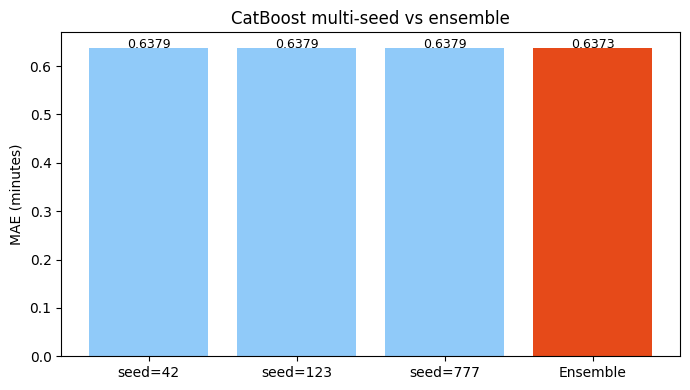

In [5]:
t0 = time.time()

CB_SEEDS = [42, 123, 777]
cb_models, cb_val_preds = [], []

for seed in CB_SEEDS:
    cb = CatBoostRegressor(
        iterations=20000, learning_rate=0.03, depth=8,
        l2_leaf_reg=3, min_data_in_leaf=30,
        loss_function='MAE', eval_metric='MAE',
        task_type=TASK_TYPE, early_stopping_rounds=200,
        random_seed=seed, verbose=0,
    )
    cb.fit(train_pool, eval_set=val_pool)
    pred  = cb.predict(fold_val[FEATURES].fillna(0))
    mae_s = mean_absolute_error(y_val, pred)
    cb_models.append(cb)
    cb_val_preds.append(pred)
    print(f'  seed={seed} | MAE val={mae_s:.4f} | best_iter={cb.best_iteration_}')

pred_val = np.mean(cb_val_preds, axis=0)
mae_val  = mean_absolute_error(y_val, pred_val)
print(f'\nCatBoost multi-seed MAE val : {mae_val:.4f}  ({time.time()-t0:.0f}s)')

# Visualisation
maes   = [mean_absolute_error(y_val, p) for p in cb_val_preds] + [mae_val]
labels = [f'seed={s}' for s in CB_SEEDS] + ['Ensemble']
colors = ['#90CAF9']*3 + ['#E64A19']
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, maes, color=colors)
for bar, v in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003, f'{v:.4f}', ha='center', fontsize=9)
plt.ylabel('MAE (minutes)'); plt.title('CatBoost multi-seed vs ensemble'); plt.tight_layout(); plt.show()

## 5. Soumission finale — réentraînement sur 100% du train

In [6]:
t0 = time.time()

# Target encoding sur 100% des données d'entraînement
stats_full = X_all.assign(p0q0=y_all).groupby('gare')['p0q0'].agg(
    gare_mean   = 'mean',
    gare_std    = 'std',
    gare_median = 'median',
    gare_q10    = lambda x: x.quantile(0.10),
    gare_q25    = lambda x: x.quantile(0.25),
    gare_q75    = lambda x: x.quantile(0.75),
    gare_q90    = lambda x: x.quantile(0.90),
    gare_p_late = lambda x: (x > 0).mean(),
).reset_index()

X_all_f = X_all.drop(columns=STAT_COLS_NAMES, errors='ignore').merge(stats_full, on='gare', how='left')
X_te_f  = X_test.drop(columns=STAT_COLS_NAMES, errors='ignore').merge(stats_full, on='gare', how='left')

for df in [X_all_f, X_te_f]:
    df['arret_x_gare_mean'] = df['arret'] * df['gare_mean']
    df['arret_x_gare_std']  = df['arret'] * df['gare_std']
    df['global_x_gare_p']   = df['mean_global'] * df['gare_p_late']

full_pool = Pool(X_all_f[FEATURES].fillna(0), y_all, cat_features=['gare_enc'])

print(f'Réentraînement CatBoost ({len(CB_SEEDS)} seeds) sur 100% train...')
test_preds = []
for seed, cb_s in zip(CB_SEEDS, cb_models):
    cb_f = CatBoostRegressor(
        iterations=cb_s.best_iteration_, learning_rate=0.03, depth=8,
        l2_leaf_reg=3, min_data_in_leaf=30,
        loss_function='MAE', task_type=TASK_TYPE,
        random_seed=seed, verbose=0,
    )
    cb_f.fit(full_pool)
    test_preds.append(cb_f.predict(X_te_f[FEATURES].fillna(0)))
    print(f'  seed={seed} done')

pred_final = np.clip(np.round(np.mean(test_preds, axis=0)).astype(int), -15, 15)

submission = pd.DataFrame({'Unnamed: 0': X_test_raw.index, 'p0q0': pred_final})
submission.to_csv('submission_simple.csv', index=False)

print(f'\nsubmission_simple.csv sauvegardé ({time.time()-t0:.0f}s)')
print(f'Distribution : {submission["p0q0"].describe().round(2).to_dict()}')

Réentraînement CatBoost (3 seeds) sur 100% train...


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=42 done


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=123 done


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=777 done

submission_simple.csv sauvegardé (1148s)
Distribution : {'count': 20657.0, 'mean': -0.05, 'std': 0.88, 'min': -13.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 3.0}
